# Stock Transformer — end-to-end run

Predict SPY's next-day candle (open, high, low, close) with a transformer that treats every `(ticker, day)` OHLCV bar as a single token — the same way a language model treats words in a sentence.

## What this notebook does

End-to-end training and evaluation against the data already cached on disk. No network calls; no `ALPHAVANTAGE_API_KEY` required as long as `data/processed/ohlcv.parquet` exists.

1. **Setup** — make `src/` importable, load env vars, set seed and pick the best torch device (CUDA → MPS → CPU).
2. **Load OHLCV** — read the bulk-downloaded parquet, slice to the symbols/date range we want, pivot into the per-symbol DataFrames the rest of the pipeline expects.
3. **Inventory** — show the equity/ETF split discovered during the bulk download and the parquet families that live next to the OHLCV panel.
4. **Explore the universe** — SPY price, peak-to-trough drawdown, daily log-return distribution, normalized growth across the basket.
5. **Macro context** — overlay CPI, effective fed funds rate, and the 10-yr treasury yield against SPY for the same window.
6. **Features + split** — convert candles to log-return tokens and split chronologically (no shuffling).
7. **Train** — a tiny `CandleTransformer` with AdamW + early stopping on validation MSE.
8. **Evaluate** — per-channel MSE, direction-of-close accuracy, predicted-vs-actual line plots, predicted-vs-actual close scatter, and a zero-cost long/short PnL proxy.
9. **Next-day forecast** — feed the most recent `lookback` days through the trained model and convert predicted log-returns back into dollar OHLC for the next session.

## Architecture in one picture

```
  raw API JSONs                  Parquet panel                  Tensors                  Model
  ────────────────────           ───────────────────────        ────────────────         ──────────────────
  data/raw/                      data/processed/                X: [N, L*S, 5]           CandleTransformer
    time_series_daily/             ohlcv.parquet                tokens / sample            d_model=64
    company_overview/        →     fundamentals/*.parquet  →    log-returns of OHLC  →    nhead=4
    income_statement/              corporate_actions/*.parquet  log1p(volume)              num_layers=3
    balance_sheet/                 macro/*.parquet              y: [N, 4]                  → SPY token at day L-1
    cash_flow/  earnings/          _universe_split.json         next-day OHLC log-r.       → 4 scalar predictions
    etf_profile/  dividends/                                                                  (open/high/low/close
    splits/  macro/                                                                            log-returns)
```

## How "candle as a token" works

For a `lookback`-day window over `S` aligned symbols the input is a sequence of `L * S` tokens, ordered day-major: `[(d0,sym0), (d0,sym1), …, (dL-1,symS-1)]`. Each token carries 5 scalars — `log(open/prev_close)`, `log(high/prev_close)`, `log(low/prev_close)`, `log(close/prev_close)`, and `log1p(volume)` — projected to `d_model` and summed with a **ticker embedding** (which ticker is this token?) plus a **positional embedding** (which day?). After `num_layers` of self-attention, only the **SPY token at the most recent day** is fed into a linear head that emits four scalars: next-day open / high / low / close as log-returns from today's SPY close.

## Where everything lives

| What | Path |
|---|---|
| Notebook entry point | `run.ipynb` (this file) |
| CLI entry point (mirror) | `run.py` |
| Training defaults | `configs/default.yaml` |
| Bulk-download manifest | `configs/download.yaml` |
| Bulk-download CLI | `scripts/download_data.py` (full design in [`docs/data_download.md`](docs/data_download.md)) |
| Fetch + align (small online path) | `src/stock_transformer/data.py` |
| Bulk download orchestration | `src/stock_transformer/av_download.py` |
| Per-endpoint parsers | `src/stock_transformer/av_parsers.py` |
| Feature builder | `src/stock_transformer/features.py` |
| Model | `src/stock_transformer/model.py` |
| Training loop, evaluation, seed/device | `src/stock_transformer/train.py` |
| Aggregated panel | `data/processed/ohlcv.parquet`, `…/fundamentals/*.parquet`, `…/macro/*.parquet`, `…/corporate_actions/*.parquet` |
| Per-call cache | `data/raw/<endpoint>/<symbol>_<hash>.json` (atomic writes; apikey stripped from hash) |
| Universe routing | `data/processed/_universe_split.json` (equity / ETF / unknown buckets) |
| Per-run logs / errors | `data/processed/_run_{run_id}.log`, `…/_errors_latest.json` |

## Reproducibility & resumability primer

- **Seeded everything** — `seed_everything` sets numpy + torch (+ CUDA) seeds (default 42).
- **Atomic cache** — every API response is written `*.tmp` then `os.replace`d, so SIGKILL never leaves a half-written JSON.
- **Per-endpoint TTL** — OHLCV refreshes daily, fundamentals every 30 days, etc.; within the window all calls are cache-only.
- **SIGINT-safe** — Ctrl-C in the bulk download flushes logs, dumps `_errors_{run_id}.json`, and exits 130; re-run picks up from cache.
- **Stale-cache fallback** — if a TTL refetch fails the cached file is served and a `WARNING` is logged; watch the `stale_fallbacks` counter.

If `data/processed/ohlcv.parquet` is missing, run the bulk-download pipeline first (`python scripts/download_data.py --dry-run` to estimate, then drop the flag) — see *Bulk download* in the README.

## 0. Setup

Make `src/` importable, load environment variables, then pick a torch device and seed.

`get_device()` prefers CUDA, falls back to Apple MPS, and finally CPU. `seed_everything()` seeds `numpy`, `torch` (and CUDA if present) so the chronological split, weight init, and DataLoader shuffle order are all reproducible from the `seed` in `configs/default.yaml`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# The project ships as an editable install (`pip install -e .`), but this notebook
# is also designed to run straight out of a fresh clone — so we patch sys.path
# with the on-disk `src/` if it isn't already importable. Idempotent.
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").is_dir() and str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Project modules. Each has a single, narrow responsibility:
#   data.align_universe       — inner-join multi-ticker candles onto a shared trading calendar
#   features.build_features   — turn aligned candles into [N, L*S, 5] log-return tokens + [N, 4] targets
#   model.CandleTransformer   — the encoder + 4-output regression head
#   train.{train_model, evaluate, split_data, seed_everything, get_device}
#                             — training loop, metrics, chronological split, RNG seeding, device picker
from stock_transformer.data import align_universe
from stock_transformer.features import build_features
from stock_transformer.model import CandleTransformer
from stock_transformer.train import (
    evaluate,
    get_device,
    seed_everything,
    split_data,
    train_model,
)

# `.env` provides ALPHAVANTAGE_API_KEY for the online fetch path. Not required
# for this notebook because we read everything from `data/processed/ohlcv.parquet`.
load_dotenv()

# All paths the notebook touches are anchored under `data/`.
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OHLCV_PARQUET = PROCESSED_DIR / "ohlcv.parquet"          # primary OHLCV panel, key=(symbol, date)
MACRO_DIR = PROCESSED_DIR / "macro"                      # CPI, fed funds, treasury yields, etc.
FUND_DIR = PROCESSED_DIR / "fundamentals"                # company_overview / income / balance / ...
CORP_DIR = PROCESSED_DIR / "corporate_actions"           # dividends.parquet, splits.parquet
UNIVERSE_SPLIT = PROCESSED_DIR / "_universe_split.json"  # phase-1 equity/ETF/unknown buckets

print(f"Project root: {PROJECT_ROOT}")
print(f"OHLCV parquet exists: {OHLCV_PARQUET.is_file()} ({OHLCV_PARQUET})")
print(f"torch:  {torch.__version__}")
print(f"numpy:  {np.__version__}")
print(f"pandas: {pd.__version__}")

Project root: /Users/dev/Documents/stock-transformer
OHLCV parquet exists: True (/Users/dev/Documents/stock-transformer/data/processed/ohlcv.parquet)
torch:  2.11.0
numpy:  2.4.4
pandas: 3.0.2


In [2]:
# Load the same defaults the CLI uses (`run.py`). Everything below is just an
# in-memory override; the YAML on disk is left untouched.
#
# Knobs you'll likely play with:
#   symbols       — token vocabulary (every symbol must be present in ohlcv.parquet)
#   target_symbol — which symbol's next-day candle is the regression target
#   lookback      — number of trading days per sample (sequence length = lookback * len(symbols))
#   start_date    — clip OHLCV history; restricting to one regime often changes results dramatically
#   d_model / nhead / num_layers / dropout — transformer capacity vs. sample efficiency
#   epochs / batch_size / learning_rate    — optimization budget; train_model uses AdamW + early stop
#   seed          — reproducibility seed (numpy + torch + CUDA)
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"
with open(CONFIG_PATH) as f:
    cfg: dict = yaml.safe_load(f)

# `setdefault` only fills in keys missing from the YAML; existing keys win.
cfg.setdefault("symbols", ["SPY", "QQQ", "AAPL", "MSFT", "GOOGL"])
cfg.setdefault("target_symbol", "SPY")
cfg.setdefault("start_date", "2010-01-01")  # None = use full history available in the parquet
cfg.setdefault("end_date", None)

# Seed BEFORE device selection so any device-dependent RNG (CUDA) is deterministic.
seed_everything(cfg["seed"])
device = get_device()  # CUDA → MPS → CPU

print(f"Config:        {CONFIG_PATH.relative_to(PROJECT_ROOT)}")
print(f"Device:        {device}")
print(f"Symbols:       {cfg['symbols']}")
print(f"Target symbol: {cfg['target_symbol']}")
print(f"Lookback:      {cfg['lookback']} days")
print(f"Date range:    {cfg['start_date']} → {cfg['end_date'] or 'latest'}")

Config:        configs/default.yaml
Device:        mps
Symbols:       ['SPY', 'QQQ', 'AAPL', 'MSFT', 'GOOGL']
Target symbol: SPY
Lookback:      30 days
Date range:    2010-01-01 → latest


## 1. Load OHLCV from cache

The bulk-download pipeline writes a single long-format parquet with primary key `(symbol, date)`:

```
ohlcv.parquet
  symbol  date        open  high  low  close  adjusted_close  volume  dividend_amount  split_coefficient
  AAPL    1999-11-01  …
  ...
```

The training pipeline expects a different shape — one DataFrame per symbol, columns `[timestamp, open, high, low, close, volume]`, all sharing the same trading calendar:

```python
{
  "SPY":   DataFrame(timestamp, open, high, low, close, volume),
  "QQQ":   DataFrame(...),
  ...
}
```

`load_universe_from_parquet` does that pivot, picking `adjusted_close` as `close` so splits and dividends are already baked in (matches `data._parse_daily` from the online path). `align_universe` then inner-joins every symbol onto the shared trading days.

In [3]:
def load_universe_from_parquet(
    symbols: list[str],
    parquet_path: Path,
    start_date: str | None = None,
    end_date: str | None = None,
) -> dict[str, pd.DataFrame]:
    """Read the bulk OHLCV parquet and reshape it into the {symbol: candle DataFrame} format.

    Output schema mirrors :func:`stock_transformer.data.fetch_universe` so the rest
    of the pipeline (``align_universe`` → ``build_features``) doesn't know whether
    candles came from the parquet or the online API.
    """
    # Hard fail (not a silent online fallback) — running the bulk pipeline is a
    # deliberate, multi-minute operation; we don't want it to start unannounced.
    if not parquet_path.is_file():
        raise FileNotFoundError(
            f"{parquet_path} is missing — run `python scripts/download_data.py` first "
            "(or fall back to `fetch_universe` for a small online fetch)."
        )

    # Normalize ticker casing once; everything downstream uses upper-case.
    wanted = [s.upper() for s in symbols]

    # Project only the columns we need. The parquet also stores `close` (un-adjusted),
    # `dividend_amount`, and `split_coefficient`, but we want adjusted-close as our
    # "close" to keep returns continuous across splits and dividends.
    df = pd.read_parquet(parquet_path, columns=[
        "symbol", "date", "open", "high", "low", "adjusted_close", "volume",
    ])
    df = df[df["symbol"].isin(wanted)].copy()

    # If the user asks for a symbol the bulk download didn't capture, fail loudly
    # rather than silently producing a smaller universe than requested.
    missing = sorted(set(wanted) - set(df["symbol"].unique()))
    if missing:
        raise KeyError(f"Symbols missing from {parquet_path.name}: {missing}")

    # Optional date clipping. Useful for restricting to a single regime
    # (e.g. post-GFC, post-COVID) without rewriting the parquet.
    if start_date is not None:
        df = df[df["date"] >= pd.Timestamp(start_date)]
    if end_date is not None:
        df = df[df["date"] <= pd.Timestamp(end_date)]

    # Rename to match the schema the model code expects.
    df = df.rename(columns={"date": "timestamp", "adjusted_close": "close"})
    df = df[["symbol", "timestamp", "open", "high", "low", "close", "volume"]]

    # Pivot: one DataFrame per ticker, sorted ascending by date, index reset so
    # positional indexing (used in build_features) lines up across symbols.
    out: dict[str, pd.DataFrame] = {}
    for sym in wanted:
        sub = (
            df[df["symbol"] == sym]
            .drop(columns="symbol")
            .sort_values("timestamp")
            .reset_index(drop=True)
        )
        out[sym] = sub
        print(
            f"  {sym:<6s} {len(sub):>5d} rows  "
            f"{sub['timestamp'].min().date()} → {sub['timestamp'].max().date()}"
        )
    return out


# Pivot once; align once. `align_universe` inner-joins on `timestamp`, so the
# longest series (typically SPY) gets clipped to the shortest one (often the
# newest IPO in the basket).
candles = load_universe_from_parquet(
    cfg["symbols"], OHLCV_PARQUET, cfg["start_date"], cfg["end_date"]
)
aligned = align_universe(candles)

  SPY     4102 rows  2010-01-04 → 2026-04-24
  QQQ     4102 rows  2010-01-04 → 2026-04-24
  AAPL    4102 rows  2010-01-04 → 2026-04-24
  MSFT    4102 rows  2010-01-04 → 2026-04-24
  GOOGL   4102 rows  2010-01-04 → 2026-04-24
  Aligned 5 symbols on 4102 common trading days
  Date range: 2010-01-04 to 2026-04-24


## 2. Data inventory

The bulk-download pipeline produces more than just OHLCV. For data analysis the panel comes with three sibling families — fundamentals, corporate actions, and macro — plus a phase-1 routing artifact (`_universe_split.json`) that records which symbols were classified as equities vs. ETFs. The cells below survey what's actually present on disk so you can see which auxiliary signals are available for future iterations of the model.

The model in this notebook only consumes OHLCV; the rest is here for context and exploration.

In [4]:
import json

# 1) Equity / ETF / unknown buckets — written by phase 1 of the bulk download.
#    Useful when slicing fundamentals (which only exist for equities) vs. ETF
#    profile data.
if UNIVERSE_SPLIT.is_file():
    split = json.loads(UNIVERSE_SPLIT.read_text())
    counts = {k: len(v) for k, v in split.items() if isinstance(v, list)}
    print("Universe split (from data/processed/_universe_split.json):")
    for k, n in sorted(counts.items(), key=lambda kv: -kv[1]):
        print(f"  {k:<10s} {n:>4d} symbols")
else:
    print("(no _universe_split.json — bulk download with fundamentals=true to generate)")

# 2) Sibling parquet families. Each is keyed differently (see docs/data_download.md):
#    fundamentals/income_statement.parquet  — (symbol, fiscalDateEnding, frequency)
#    corporate_actions/dividends.parquet    — (symbol, ex_dividend_date)
#    macro/treasury_yield.parquet           — (maturity, date)
#    macro/cpi.parquet                      — (date)
def _summarize(path: Path) -> str:
    if not path.is_file():
        return f"  [skip] {path.relative_to(PROCESSED_DIR)} not present"
    n = len(pd.read_parquet(path, columns=[]))
    size_mb = path.stat().st_size / 1_048_576
    return f"  {str(path.relative_to(PROCESSED_DIR)):<45s} {n:>9,d} rows  ({size_mb:6.2f} MB)"

print("\nParquet inventory (data/processed/):")
for sub in [
    OHLCV_PARQUET,
    FUND_DIR / "company_overview.parquet",
    FUND_DIR / "income_statement.parquet",
    FUND_DIR / "balance_sheet.parquet",
    FUND_DIR / "cash_flow.parquet",
    FUND_DIR / "earnings.parquet",
    FUND_DIR / "etf_profile.parquet",
    CORP_DIR / "dividends.parquet",
    CORP_DIR / "splits.parquet",
    MACRO_DIR / "cpi.parquet",
    MACRO_DIR / "federal_funds_rate.parquet",
    MACRO_DIR / "treasury_yield.parquet",
    MACRO_DIR / "real_gdp.parquet",
    MACRO_DIR / "unemployment.parquet",
]:
    print(_summarize(sub))

Universe split (from data/processed/_universe_split.json):
  Common Stock  488 symbols
  Unknown      14 symbols
  ETF           0 symbols

Parquet inventory (data/processed/):
  ohlcv.parquet                                         0 rows  ( 69.42 MB)
  fundamentals/company_overview.parquet                 0 rows  (  0.23 MB)
  fundamentals/income_statement.parquet                 0 rows  (  4.12 MB)
  fundamentals/balance_sheet.parquet                    0 rows  (  6.76 MB)
  fundamentals/cash_flow.parquet                        0 rows  (  2.65 MB)
  fundamentals/earnings.parquet                         0 rows  (  0.43 MB)
  fundamentals/etf_profile.parquet                      0 rows  (  0.00 MB)
  corporate_actions/dividends.parquet                   0 rows  (  0.16 MB)
  corporate_actions/splits.parquet                      0 rows  (  0.01 MB)
  macro/cpi.parquet                                     0 rows  (  0.02 MB)
  macro/federal_funds_rate.parquet                      0 rows 

## 3. Explore the universe

Quick sanity checks before training:

- **Adjusted close** — the actual price series the model will be conditioned on.
- **Drawdown from running max** — peak-to-trough loss; a sharp dip in 2020 / 2022 / etc. confirms the regime makes it into the slice.
- **Daily log-return distribution** — its standard deviation σ is the realized volatility; targets the model has to predict will live on the same scale.
- **Per-symbol stats table** — first/last date, row count, average close, daily-return σ.
- **Normalized growth** — every symbol rebased to 1.0 at the start of the aligned window, plotted on a log y-axis (linear differences = compounded returns).

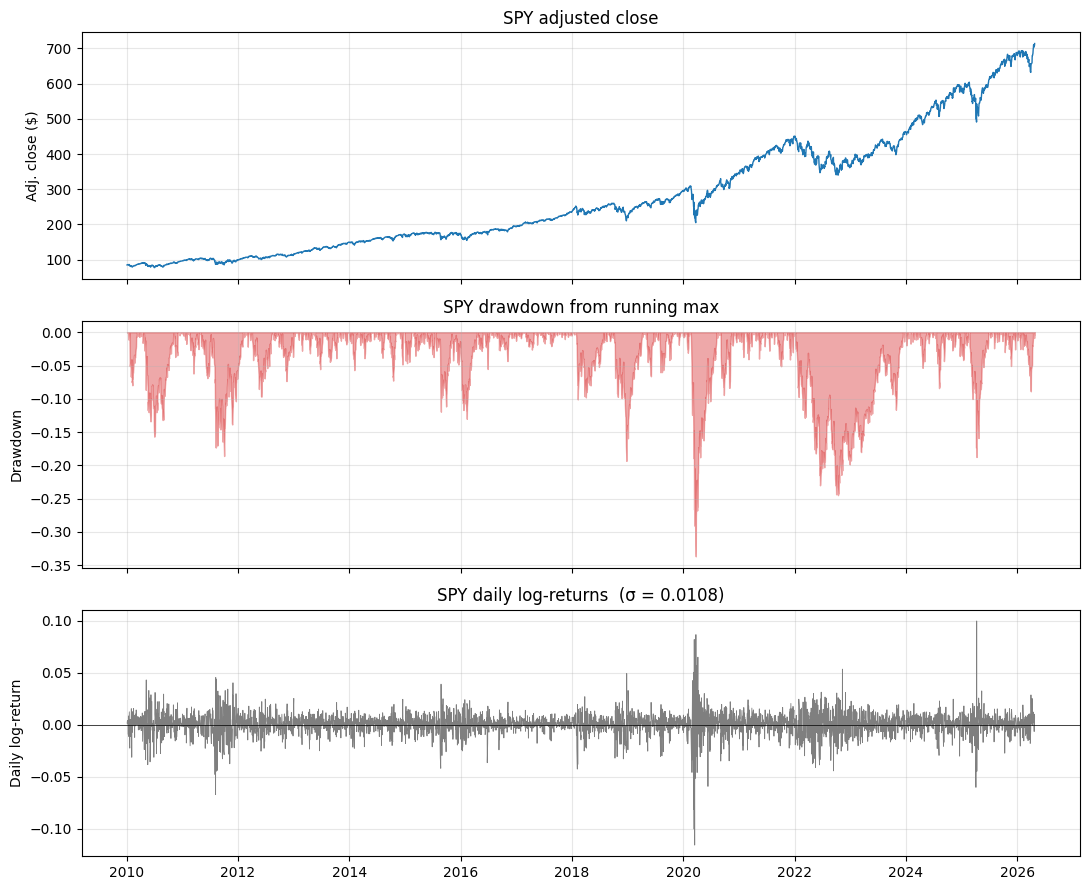

,first,last,rows,avg_close,daily_vol
SPY,2010-01-04,2026-04-24,4102,275.82,0.0108
QQQ,2010-01-04,2026-04-24,4102,208.43,0.0130
AAPL,2010-01-04,2026-04-24,4102,80.93,0.0177
MSFT,2010-01-04,2026-04-24,4102,154.31,0.0162
GOOGL,2010-01-04,2026-04-24,4102,74.91,0.0174


In [5]:
target_sym = cfg["target_symbol"].upper()
spy = aligned[target_sym].set_index("timestamp")

# Daily log-return = log(close_t / close_{t-1}). Log-returns are additive across
# time, symmetric around 0, and what build_features uses for the targets — so
# anything we observe here is the same scale the model is fitting to.
spy_ret = np.log(spy["close"]).diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(spy.index, spy["close"], color="tab:blue", lw=1.0)
axes[0].set_ylabel("Adj. close ($)")
axes[0].set_title(f"{target_sym} adjusted close")
axes[0].grid(alpha=0.3)

# Drawdown = current_close / running_peak - 1. Always ≤ 0; trough = max loss.
running_max = spy["close"].cummax()
drawdown = spy["close"] / running_max - 1.0
axes[1].fill_between(drawdown.index, drawdown.values, 0, color="tab:red", alpha=0.4)
axes[1].set_ylabel("Drawdown")
axes[1].set_title(f"{target_sym} drawdown from running max")
axes[1].grid(alpha=0.3)

axes[2].plot(spy_ret.index, spy_ret.values, color="tab:gray", lw=0.6)
axes[2].axhline(0, color="k", lw=0.5)
axes[2].set_ylabel("Daily log-return")
axes[2].set_title(f"{target_sym} daily log-returns  (σ = {spy_ret.std():.4f})")
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

# Per-symbol summary stats. `daily_vol` is the standard deviation of daily
# log-returns — a 1-σ move in the natural unit the model predicts in.
stats = pd.DataFrame({
    "first": [df["timestamp"].min().date() for df in aligned.values()],
    "last":  [df["timestamp"].max().date() for df in aligned.values()],
    "rows":  [len(df) for df in aligned.values()],
    "avg_close": [df["close"].mean() for df in aligned.values()],
    "daily_vol": [np.log(df["close"]).diff().std() for df in aligned.values()],
}, index=list(aligned.keys()))
stats.style.format({"avg_close": "{:.2f}", "daily_vol": "{:.4f}"})

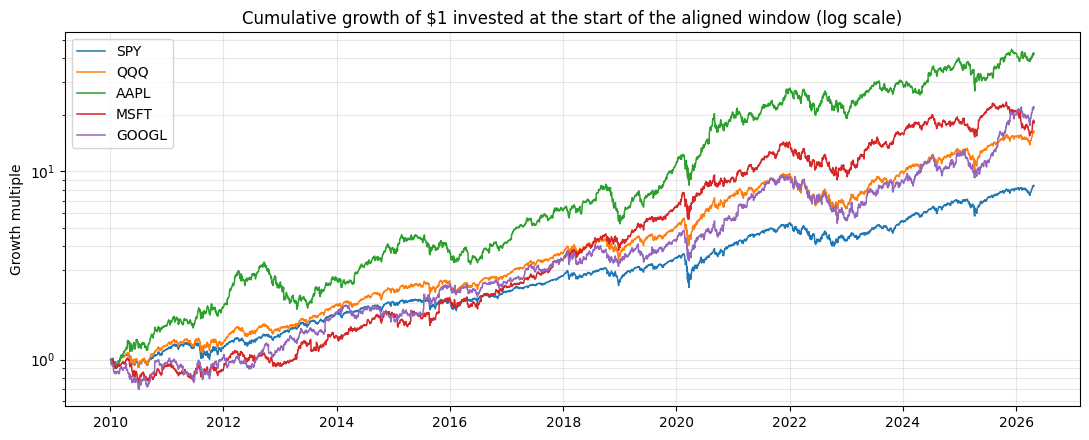

In [6]:
# Normalized growth: divide each series by its first close so every line starts
# at 1.0. Log y-axis turns "compounded returns" into "linear distance", which
# makes early/late returns directly comparable at a glance.
fig, ax = plt.subplots(figsize=(11, 4.5))
for sym, df in aligned.items():
    s = df.set_index("timestamp")["close"]
    ax.plot(s.index, s.values / s.iloc[0], lw=1.1, label=sym)
ax.set_yscale("log")
ax.set_title("Cumulative growth of $1 invested at the start of the aligned window (log scale)")
ax.set_ylabel("Growth multiple")
ax.grid(alpha=0.3, which="both")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## 4. Macro context

Overlay key macro series alongside SPY: CPI level, the effective fed-funds rate, and the 10-year treasury yield (one of six maturities stored in the long-format `treasury_yield.parquet`). The transformer doesn't ingest these directly yet, but eyeballing the regime helps interpret the chronological split — e.g. the test set ending up entirely in a hiking cycle would explain a large train/test distribution shift.

Schema reminder (from `docs/data_download.md`):
- `cpi.parquet` / `federal_funds_rate.parquet` — `(date, value)` long format.
- `treasury_yield.parquet` — `(maturity, date, value)`; `maturity ∈ {3month, 2year, 5year, 7year, 10year, 30year}`.

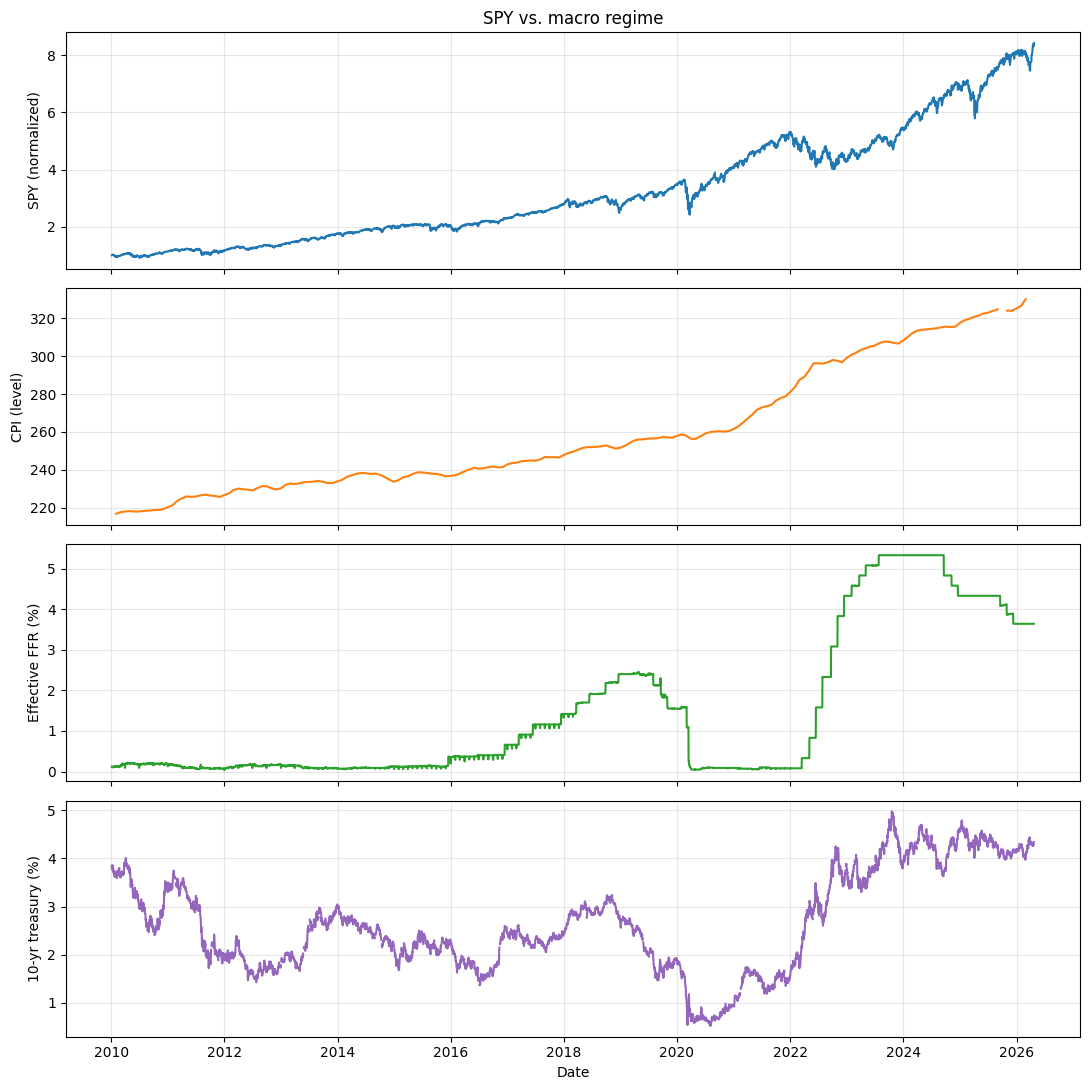

In [7]:
def _load_macro(name: str) -> pd.DataFrame | None:
    """Read a macro parquet by name, returning None (and a warning print) if missing."""
    p = MACRO_DIR / f"{name}.parquet"
    if not p.is_file():
        print(f"  [skip] {p.name} not found")
        return None
    return pd.read_parquet(p).sort_values("date")


# Restrict each macro series to SPY's window so the four panels share an x-axis.
start = spy.index.min()
end = spy.index.max()

cpi = _load_macro("cpi")
ffr = _load_macro("federal_funds_rate")
tsy = _load_macro("treasury_yield")

fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

# Top panel: SPY rebased to 1.0 — same idea as the normalized-growth chart above
# but re-rendered alongside the macro panels for visual alignment.
spy_norm = spy["close"] / spy["close"].iloc[0]
axes[0].plot(spy_norm.index, spy_norm.values, color="tab:blue")
axes[0].set_ylabel(f"{target_sym} (normalized)")
axes[0].set_title(f"{target_sym} vs. macro regime")
axes[0].grid(alpha=0.3)

# CPI is monthly; the line steps up between releases.
if cpi is not None:
    sub = cpi[(cpi["date"] >= start) & (cpi["date"] <= end)]
    axes[1].plot(sub["date"], sub["value"], color="tab:orange")
axes[1].set_ylabel("CPI (level)")
axes[1].grid(alpha=0.3)

# Effective fed funds rate, daily.
if ffr is not None:
    sub = ffr[(ffr["date"] >= start) & (ffr["date"] <= end)]
    axes[2].plot(sub["date"], sub["value"], color="tab:green")
axes[2].set_ylabel("Effective FFR (%)")
axes[2].grid(alpha=0.3)

# treasury_yield is long-format with one row per (maturity, date). Filter for
# the 10y constant-maturity series; swap to "30year" / "3month" / etc. to view
# other points on the curve.
if tsy is not None:
    sub = tsy[(tsy["maturity"] == "10year") & (tsy["date"] >= start) & (tsy["date"] <= end)]
    axes[3].plot(sub["date"], sub["value"], color="tab:purple")
axes[3].set_ylabel("10-yr treasury (%)")
axes[3].grid(alpha=0.3)
axes[3].set_xlabel("Date")

fig.tight_layout()
plt.show()

## 5. Build features and split

`build_features` (in `src/stock_transformer/features.py`) does the heavy lifting:

**Per token (one (day, ticker) pair) — 5 scalars:**

```
feat[t, j, 0] = log(open[t,  j] / close[t-1, j] + ε)
feat[t, j, 1] = log(high[t,  j] / close[t-1, j] + ε)
feat[t, j, 2] = log(low[t,   j] / close[t-1, j] + ε)
feat[t, j, 3] = log(close[t, j] / close[t-1, j] + ε)
feat[t, j, 4] = log1p(volume[t, j])              ← scale-stable, handles 0-volume days
```

**Per sample — input shape `[L*S, 5]`:**

```
window = feat[t-L+1 : t+1]    # [L, S, 5]   most recent L days × S symbols
flat   = window.reshape(L*S, 5)               # day-major: (d0,sym0), (d0,sym1), …, (dL-1,symS-1)
```

**Per sample — target shape `[4]`** (target = next-day SPY OHLC as log-returns from today's close):

```
target[t] = log(SPY_OHLC[t+1] / SPY_close[t] + ε)
```

**Valid sample range** — day index `t` runs from `lookback` to `n_days - 2` (need `t-1` for prev-close and `t+1` for the target), so `N = n_days - lookback - 1`.

**Split** — chronological. No shuffling: `train` = first 70 %, `val` = next 15 %, `test` = last 15 %. Anything else leaks the future into training.

  Built 4071 samples, each with 30x5=150 tokens
  Target: SPY next-day OHLC log-returns
  Split: train=2849, val=611, test=611

X shape: (4071, 150, 5)  (samples, lookback*n_symbols, features)
y shape: (4071, 4)  (samples, [open, high, low, close] log-returns)
Symbol order: ['SPY', 'QQQ', 'AAPL', 'MSFT', 'GOOGL']


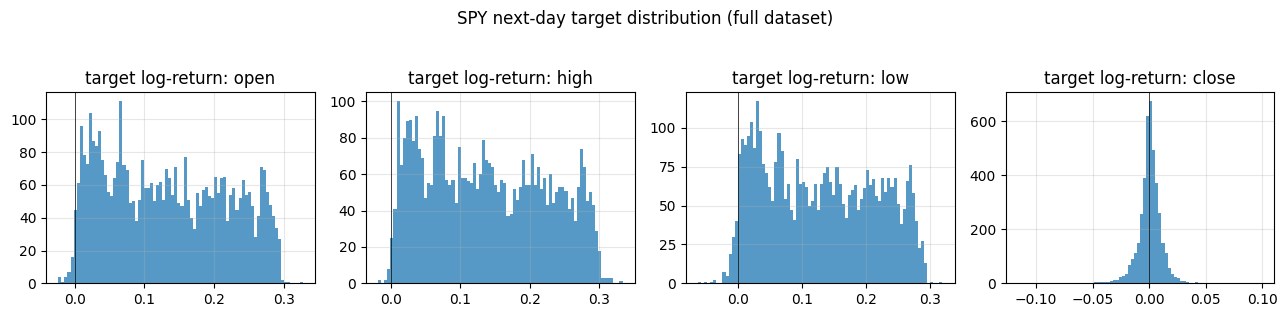

In [8]:
# build_features returns:
#   X:       [N, L*S, 5]  L*S tokens per sample, 5 features each
#   y:       [N, 4]       next-day OHLC log-returns of the target symbol
#   symbols: ordered list of tickers; defines the symbol axis (index → ticker_id in the model)
X, y, symbols = build_features(aligned, cfg["target_symbol"], cfg["lookback"])

# Strict chronological split (no shuffling). Time-series CV would be even better
# but adds complexity; this is the conservative single-split baseline.
train_data, val_data, test_data = split_data(X, y, cfg["train_pct"], cfg["val_pct"])

print(f"\nX shape: {tuple(X.shape)}  (samples, lookback*n_symbols, features)")
print(f"y shape: {tuple(y.shape)}  (samples, [open, high, low, close] log-returns)")
print(f"Symbol order: {symbols}")

# Histogram each target channel on the FULL dataset (train+val+test combined).
# Eyeballing this catches outliers and confirms the distribution is roughly
# zero-centered — important since the model uses MSE loss, which is symmetric.
labels = ["open", "high", "low", "close"]
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for i, name in enumerate(labels):
    axes[i].hist(y[:, i].numpy(), bins=80, color="tab:blue", alpha=0.75)
    axes[i].set_title(f"target log-return: {name}")
    axes[i].axvline(0, color="k", lw=0.5)
    axes[i].grid(alpha=0.3)
fig.suptitle(f"{cfg['target_symbol']} next-day target distribution (full dataset)", y=1.04)
fig.tight_layout()
plt.show()

## 6. Train the transformer

`CandleTransformer` (`src/stock_transformer/model.py`) is a standard `nn.TransformerEncoder` stack with two project-specific tweaks:

```
input  x: [B, L*S, 5]
            │
            ▼
   feat_proj: Linear(5 → d_model)         # turns each candle into a d_model-dim token
            │
            ▼
   + ticker_embed[ticker_id]             # which symbol is this token (index in `symbols`)?
   + pos_embed[day_id]                    # which day in the lookback window?
            │
            ▼
   TransformerEncoder × num_layers       # multi-head self-attention + FFN, dropout=cfg.dropout
            │                              dim_feedforward = 4 * d_model, batch_first=True
            ▼
   pick token at index (L-1) * S + target_symbol_idx   # SPY's most-recent-day token
            │
            ▼
   head: Linear(d_model → 4)              # (open, high, low, close) log-returns
output y: [B, 4]
```

Training (`train_model` in `train.py`):
- **Optimizer**: `AdamW(lr=cfg["learning_rate"])`.
- **Loss**: `MSELoss` over all four target channels.
- **Early stopping**: `patience=5` epochs without val-loss improvement; best state is restored before returning.
- **Logging**: prints train/val MSE on epochs 1–5, every 5th epoch, and any new best (marked `*`).

In [9]:
# `target_symbol_idx` tells the model which token slice to read at the end:
# encoded[:, (L-1)*S + target_symbol_idx, :] is the target's most-recent-day token.
target_idx = symbols.index(cfg["target_symbol"].upper())

model = CandleTransformer(
    n_symbols=len(symbols),
    lookback=cfg["lookback"],
    d_model=cfg["d_model"],
    nhead=cfg["nhead"],
    num_layers=cfg["num_layers"],
    dropout=cfg["dropout"],
    target_symbol_idx=target_idx,
)
total_params = sum(p.numel() for p in model.parameters())
print(
    f"Model: {total_params:,} parameters  |  "
    f"d_model={cfg['d_model']}  nhead={cfg['nhead']}  layers={cfg['num_layers']}"
)

# train_model handles: device move, AdamW, MSE, batched DataLoader (shuffle=True
# within the train fold — that's fine, it doesn't leak time across fold
# boundaries), val-set eval each epoch, early stopping (patience=5), and
# best-checkpoint restore.
model = train_model(
    model,
    train_data,
    val_data,
    epochs=cfg["epochs"],
    batch_size=cfg["batch_size"],
    learning_rate=cfg["learning_rate"],
    device=device,
)

Model: 152,836 parameters  |  d_model=64  nhead=4  layers=3


  Epoch   1  train=0.016945  val=0.001535 *


  Epoch   2  train=0.003828  val=0.000838 *


  Epoch   3  train=0.002381  val=0.000946


  Epoch   4  train=0.001788  val=0.000385 *


...

  Epoch  14  train=0.000682  val=0.000155 *


  Epoch  15  train=0.000631  val=0.000214


  Epoch  16  train=0.000664  val=0.000124 *


  Epoch  20  train=0.000669  val=0.001571


  Early stopping at epoch 21 (no improvement for 5 epochs)


## 7. Evaluate on the held-out test set

`evaluate(model, test_data, device)` reports:
- per-channel MSE (open / high / low / close)
- aggregate MSE across all four channels
- direction-of-close accuracy: `sign(predicted close return) == sign(actual close return)` on the test fold

Then we re-run the model on the test set to get raw predictions for the line / scatter / PnL plots below. These views are complementary:

- **Line plots** — does the model track the actual series, or is it predicting a flat zero?
- **Pred-vs-actual scatter** — slope ≈ 1 means well-calibrated magnitude; cluster around 0 with no slope means the model is mostly predicting "small move".
- **Long/short PnL proxy** — the most generous *trading* metric: assume zero costs and trade the sign of the prediction. If this isn't above buy-and-hold, the model isn't producing tradable signal in this regime.

In [10]:
# Built-in metrics: per-channel MSE + close-direction accuracy.
evaluate(model, test_data, device)

# Re-run inference on the test set so we have raw arrays to plot.
# torch.no_grad() avoids building the autograd graph (faster + lower memory).
test_X, test_y = test_data[0].to(device), test_data[1].to(device)
model.eval()
with torch.no_grad():
    test_pred = model(test_X).cpu().numpy()
test_actual = test_y.cpu().numpy()


  === Test Results ===
  MSE  open: 0.000846
  MSE  high: 0.001042
  MSE   low: 0.000823
  MSE close: 0.000111
  MSE total: 0.000706
  Direction accuracy (close): 42.1%
  Test samples: 611


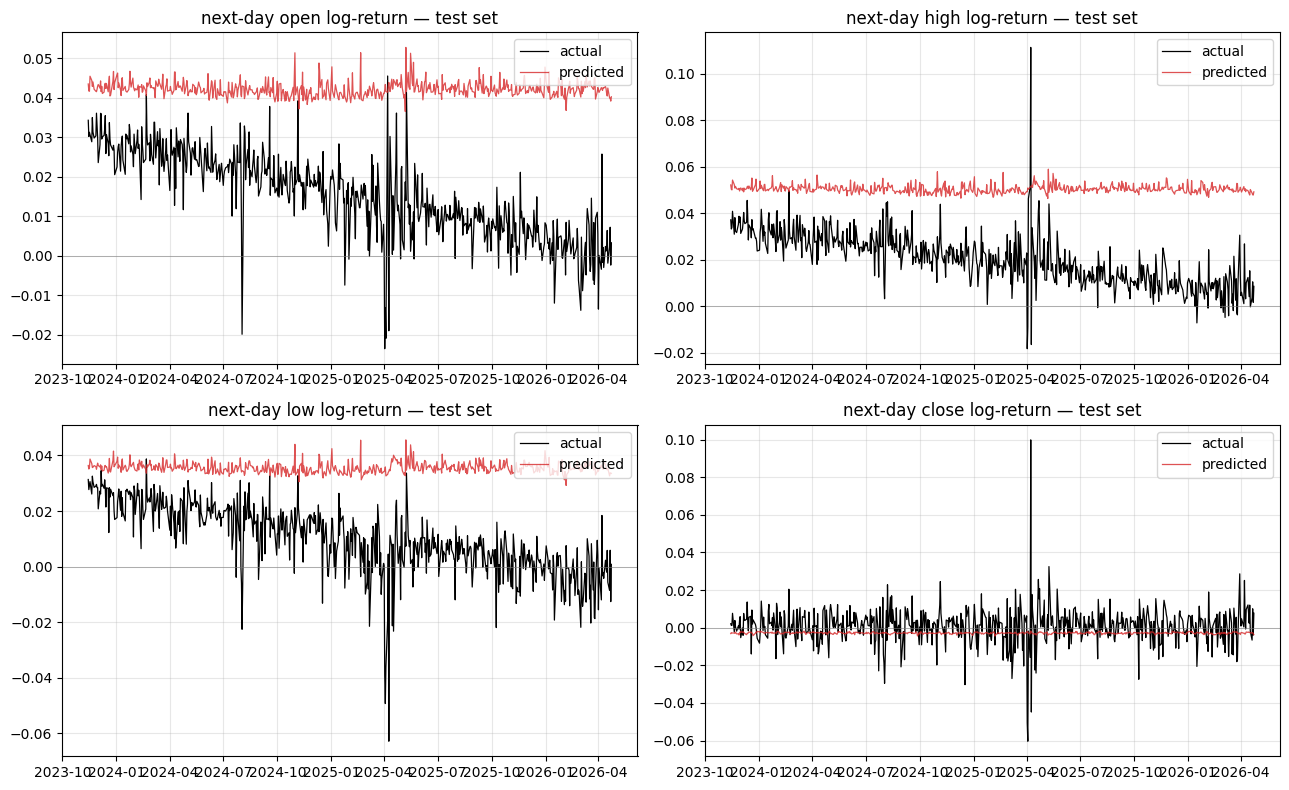

In [11]:
# Map every prediction back to the calendar date it was made on.
#
# build_features iterates `t` over `[valid_start + lookback - 1, valid_end)`
# where `valid_start = 1` (need a prev-close) and `valid_end = n_days - 1`
# (need a next-day target). So sample i corresponds to "today" = day index
# `i + lookback` in the aligned panel.
n_total = len(X)
n_train = int(n_total * cfg["train_pct"])
n_val = int(n_total * (cfg["train_pct"] + cfg["val_pct"]))

spy_dates = aligned[target_sym]["timestamp"].reset_index(drop=True)
sample_today_dates = spy_dates.iloc[cfg["lookback"] : len(spy_dates) - 1].reset_index(drop=True)
assert len(sample_today_dates) == n_total, (len(sample_today_dates), n_total)

# split_data splits in the same order, so the test fold occupies [n_val:].
test_dates = sample_today_dates.iloc[n_val:].reset_index(drop=True)

# Four panels: one per OHLC channel. Black line = actual next-day log-return,
# red line = model's prediction. A model with no signal will hover near 0.
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, (name, ax) in enumerate(zip(labels, axes.flat)):
    ax.plot(test_dates, test_actual[:, i], color="k",       lw=0.9, label="actual")
    ax.plot(test_dates, test_pred[:, i],   color="tab:red", lw=0.9, alpha=0.8, label="predicted")
    ax.axhline(0, color="gray", lw=0.4)
    ax.set_title(f"next-day {name} log-return — test set")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

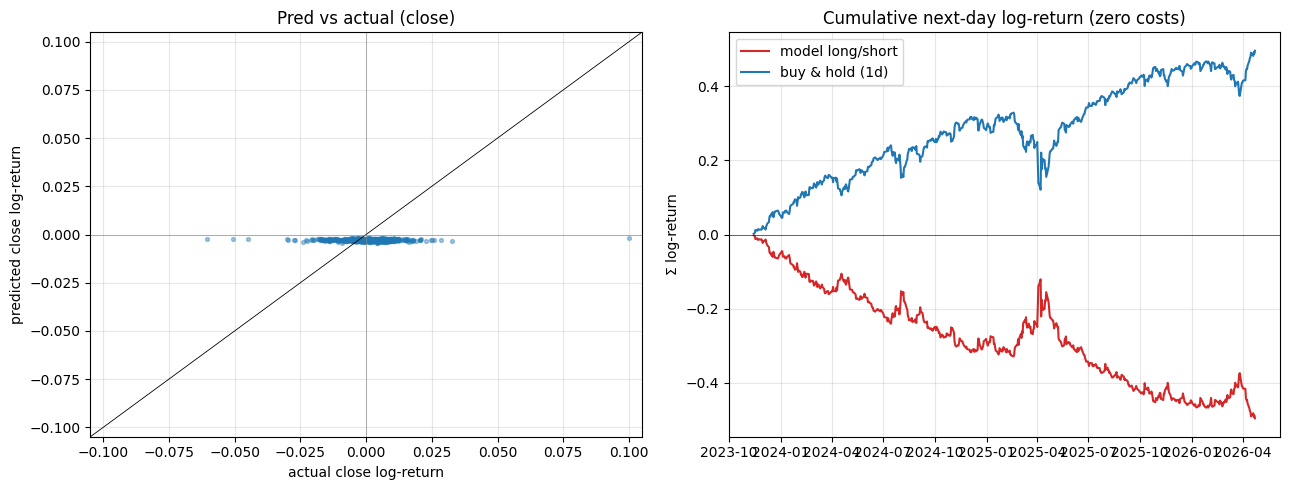

Direction hit rate (close): 42.1%
Cumulative model log-return: -0.4956  →  exp = 0.609x
Cumulative buy-and-hold:     0.4956  →  exp = 1.641x


In [12]:
# Two complementary diagnostics: calibration scatter (left) and a naive PnL proxy (right).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Slice out the close-return channel (index 3 of [open, high, low, close]).
p_close = test_pred[:, 3]
a_close = test_actual[:, 3]

# LEFT: predicted vs actual scatter, zoomed to the largest move on either axis.
# A perfectly calibrated model would have points clustered along the y=x line.
lim = max(abs(p_close).max(), abs(a_close).max()) * 1.05
axes[0].scatter(a_close, p_close, s=8, alpha=0.4)
axes[0].plot([-lim, lim], [-lim, lim], color="k", lw=0.6)  # 45° identity reference
axes[0].axhline(0, color="gray", lw=0.4)
axes[0].axvline(0, color="gray", lw=0.4)
axes[0].set_xlim(-lim, lim)
axes[0].set_ylim(-lim, lim)
axes[0].set_xlabel("actual close log-return")
axes[0].set_ylabel("predicted close log-return")
axes[0].set_title("Pred vs actual (close)")
axes[0].grid(alpha=0.3)

# RIGHT: zero-cost long/short toy strategy. position = sign(prediction):
#   pred > 0  → long  → realized log-return = +actual
#   pred < 0  → short → realized log-return = -actual
# Cumulative log-returns are additive, so a naive sum gives the equity curve in
# log space. Compare against buy & hold (always long).
#
# CAVEATS:
# - Costs, slippage, and bid-ask are ZERO here. Real trading erodes alpha fast.
# - This treats every prediction as a 100% notional bet — no sizing.
# - Same window as the train fold's regime; out-of-sample generalization is the
#   whole point of this plot.
position = np.sign(p_close)
daily_pnl = position * a_close
buy_hold = a_close
axes[1].plot(test_dates, np.cumsum(daily_pnl), color="tab:red",  label="model long/short")
axes[1].plot(test_dates, np.cumsum(buy_hold),  color="tab:blue", label="buy & hold (1d)")
axes[1].axhline(0, color="k", lw=0.4)
axes[1].set_title("Cumulative next-day log-return (zero costs)")
axes[1].set_ylabel("Σ log-return")
axes[1].grid(alpha=0.3)
axes[1].legend()
fig.tight_layout()
plt.show()

# Sanity-check numbers: hit rate and total log-return → multiplicative growth via exp().
hit_rate = float((np.sign(p_close) == np.sign(a_close)).mean())
print(f"Direction hit rate (close): {hit_rate:.1%}")
print(f"Cumulative model log-return: {daily_pnl.sum():.4f}  →  exp = {np.exp(daily_pnl.sum()):.3f}x")
print(f"Cumulative buy-and-hold:     {buy_hold.sum():.4f}  →  exp = {np.exp(buy_hold.sum()):.3f}x")

## 8. Predict the next trading day

The model is trained to predict next-day OHLC log-returns from the previous `lookback` days. To produce a real-money forecast for the next session:

1. **Feature window** — repeat the same featurization `build_features` does (log-returns vs. previous close, log1p volume) but only for the most recent `lookback` days. No target: there's nothing past the last available bar yet.
2. **Forward pass** — `model(x_latest)` returns four log-returns: `(open, high, low, close)`.
3. **Convert to dollars** — `predicted_price = last_close * exp(log_return)` since the targets are log-returns from today's close.
4. **Render** — overlay the predicted candle on the last 60 sessions: a vertical bar from predicted low to predicted high, horizontal whiskers for predicted open and close, dot at the predicted close.

⚠️ This is a research toy — see the caveats above. Don't bet money on a model whose validation MSE is roughly equal to its target variance.

In [13]:
def build_latest_window(
    aligned: dict[str, pd.DataFrame], lookback: int
) -> tuple[torch.Tensor, pd.Timestamp, float]:
    """Construct a single feature window ending on the most recent available day.

    This mirrors :func:`stock_transformer.features.build_features` but only emits
    the *last* sample (no targets). Returns:

      x          : [1, L*S, 5] tensor — the model's input
      last_date  : the date of the final candle in the window (today)
      last_close : the target symbol's adjusted close on `last_date`,
                   needed to convert log-return predictions back to dollars.
    """
    syms = list(aligned.keys())
    n_days = len(next(iter(aligned.values())))
    S = len(syms)

    # Pack candles into [n_days, S, 5] (OHLCV) and the close into [n_days, S].
    ohlcv = np.zeros((n_days, S, 5), dtype=np.float64)
    close_raw = np.zeros((n_days, S), dtype=np.float64)
    for j, sym in enumerate(syms):
        df = aligned[sym]
        ohlcv[:, j, 0] = df["open"].values
        ohlcv[:, j, 1] = df["high"].values
        ohlcv[:, j, 2] = df["low"].values
        ohlcv[:, j, 3] = df["close"].values
        ohlcv[:, j, 4] = df["volume"].values
        close_raw[:, j] = df["close"].values

    # eps avoids log(0) when a price ratio rounds to ~0; safe_pc avoids
    # divide-by-zero on day 0 (no previous close exists yet).
    eps = 1e-10
    prev = np.roll(close_raw, 1, axis=0)
    prev[0, :] = np.nan
    safe_pc = np.where(prev > 0, prev, eps)

    # Same feature transform as features.build_features:
    #   OHL/C: log-return vs previous close (intraday + overnight info combined)
    #   V:     log1p so volume is on a comparable scale, robust to 0-volume days
    feats = np.zeros((n_days, S, 5), dtype=np.float64)
    feats[:, :, 0] = np.log(ohlcv[:, :, 0] / safe_pc + eps)
    feats[:, :, 1] = np.log(ohlcv[:, :, 1] / safe_pc + eps)
    feats[:, :, 2] = np.log(ohlcv[:, :, 2] / safe_pc + eps)
    feats[:, :, 3] = np.log(ohlcv[:, :, 3] / safe_pc + eps)
    feats[:, :, 4] = np.log1p(np.clip(ohlcv[:, :, 4], 0, None))
    feats[0, :, :] = 0.0  # day 0 has no prev close → zero out

    # Slice the trailing `lookback` days, flatten day×symbol → token sequence.
    window = feats[n_days - lookback : n_days].reshape(lookback * S, 5)
    x = torch.tensor(window[None], dtype=torch.float32)  # add batch dim → [1, L*S, 5]

    target_key = cfg["target_symbol"].upper()
    last_date = aligned[target_key]["timestamp"].iloc[-1]
    last_close = float(aligned[target_key]["close"].iloc[-1])
    return x, last_date, last_close


x_latest, last_date, last_close = build_latest_window(aligned, cfg["lookback"])

# Inference. The model emits 4 log-returns: (open, high, low, close) of the
# next session, expressed as log of (next_OHLC / today's close).
model.eval()
with torch.no_grad():
    pred_logret = model(x_latest.to(device)).cpu().numpy()[0]

# Invert: price = last_close * exp(log_return). Tiny log-returns (<1%) are
# nearly equal to percent changes; that's what the printed +/-% reflects.
pred_ohlc = last_close * np.exp(pred_logret)
print(f"Last close in dataset:  {last_date.date()}  {target_sym} adj close = ${last_close:,.2f}")
print()
print(f"Predicted next session ({target_sym})")
print(f"  open  ${pred_ohlc[0]:>9,.2f}   ({pred_logret[0] * 100:+.3f}%)")
print(f"  high  ${pred_ohlc[1]:>9,.2f}   ({pred_logret[1] * 100:+.3f}%)")
print(f"  low   ${pred_ohlc[2]:>9,.2f}   ({pred_logret[2] * 100:+.3f}%)")
print(f"  close ${pred_ohlc[3]:>9,.2f}   ({pred_logret[3] * 100:+.3f}%)")
direction = "UP ↑" if pred_logret[3] > 0 else "DOWN ↓"
print(f"  direction: {direction}")

Last close in dataset:  2026-04-24  SPY adj close = $713.94

Predicted next session (SPY)
  open  $   743.46   (+4.051%)
  high  $   749.97   (+4.923%)
  low   $   738.72   (+3.411%)
  close $   711.13   (-0.395%)
  direction: DOWN ↓


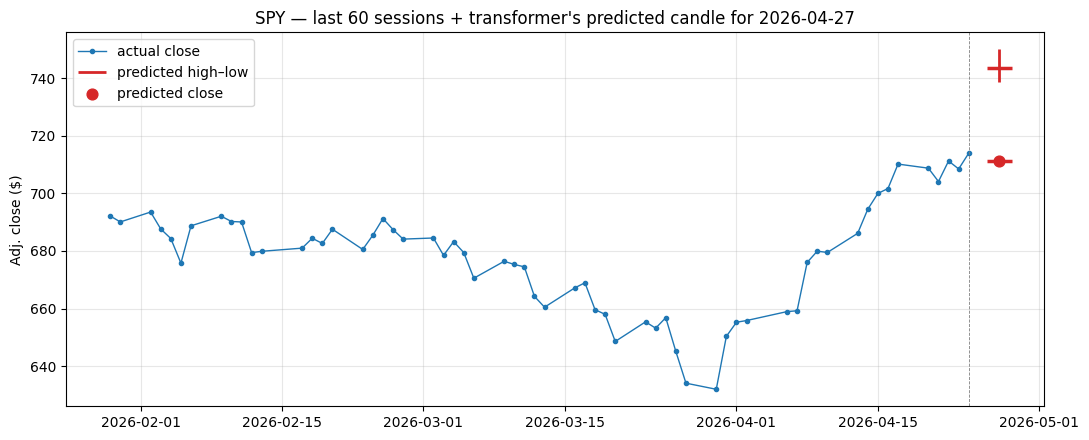

In [14]:
# Last 60 actual closes + a single predicted candle for the next business day.
# `BDay(1)` is the next weekday — note this isn't aware of US market holidays,
# so the x-axis label may shift by a day around Thanksgiving / Christmas / etc.
tail = aligned[target_sym].set_index("timestamp").tail(60)
next_date = last_date + pd.tseries.offsets.BDay(1)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(tail.index, tail["close"], color="tab:blue", marker="o", ms=3, lw=1.0, label="actual close")

# Render the predicted candle as a vertical bar (low → high) with horizontal
# whiskers at predicted open and close, and a dot at the predicted close.
ax.vlines(next_date, pred_ohlc[2], pred_ohlc[1], color="tab:red", lw=2.0, label="predicted high–low")
ax.plot([next_date], [pred_ohlc[0]], marker="_", ms=18, color="tab:red", mew=2.5)  # open whisker
ax.plot([next_date], [pred_ohlc[3]], marker="_", ms=18, color="tab:red", mew=2.5)  # close whisker
ax.scatter([next_date], [pred_ohlc[3]], color="tab:red", s=60, zorder=5, label="predicted close")
ax.axvline(last_date, color="gray", lw=0.6, ls="--")  # divider between observed and predicted
ax.set_title(f"{target_sym} — last 60 sessions + transformer's predicted candle for {next_date.date()}")
ax.set_ylabel("Adj. close ($)")
ax.grid(alpha=0.3)
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## Done.

### Knobs to play with

| Knob | Effect |
|---|---|
| `cfg["symbols"]` | Token vocabulary. Any ticker present in `data/processed/ohlcv.parquet` works. Wider basket → richer cross-asset attention but more tokens per sample (`L*S` grows). |
| `cfg["target_symbol"]` | The model can predict any aligned symbol's next-day candle, not just SPY. |
| `cfg["start_date"]` | Restricting to a single regime (post-2010, post-2015, post-COVID) often changes results dramatically. |
| `cfg["lookback"]` | Days of history per sample. Longer = more context, longer sequences, slower training. |
| `cfg["d_model"]` / `nhead` / `num_layers` | Capacity vs. sample efficiency. The defaults (64 / 4 / 3) are deliberately tiny; this dataset is small. |
| `cfg["dropout"]` | Increase if val MSE diverges from train MSE early. |
| `cfg["epochs"]` / `cfg["batch_size"]` / `cfg["learning_rate"]` | Optimization budget. Early stopping (patience=5) prunes overruns. |
| `cfg["seed"]` | Reproducibility seed. Try a few seeds to gauge run-to-run variance. |

### Re-running

For a different cached universe, edit `cfg["symbols"]` (cell §0) and re-run from §1. To use a freshly downloaded ticker that isn't in the parquet yet, run `python scripts/download_data.py --symbols TSLA,NVDA` (or edit `configs/download.yaml`) — the bulk pipeline appends to `data/raw/` and rebuilds the parquet idempotently.

### Where to look next

- **`docs/data_download.md`** — full design of the bulk-download pipeline, including TTLs, primary keys, error handling, and the SIGINT path.
- **`tests/`** — fast unit tests for the AV client, parsers, and download orchestration. `pytest -q` runs them all in seconds.
- **`src/stock_transformer/av_parsers.py`** — pure functions for every endpoint family; the cleanest place to start hacking on a new feature (e.g. earnings surprise as an additional token feature).